In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc



In [4]:
DATASET_DIR = "Downloads/Jaundice Eyes/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20


In [5]:
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    print(f"{cls} → {len(os.listdir(cls_path))} images")


Jaundice → 84 images
Normal → 84 images


In [6]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    return img


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [8]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class Mapping:", train_generator.class_indices)


Found 136 images belonging to 2 classes.
Found 32 images belonging to 2 classes.
Class Mapping: {'Jaundice': 0, 'Normal': 1}


In [9]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [12]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2)
]


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
9/9 [==============================] - 15s 1s/step - loss: 0.9159 - accuracy: 0.5368 - val_loss: 0.6534 - val_accuracy: 0.5312 - lr: 1.0000e-04
Epoch 2/20
9/9 [==============================] - 7s 748ms/step - loss: 0.7473 - accuracy: 0.5588 - val_loss: 0.6193 - val_accuracy: 0.6562 - lr: 1.0000e-04
Epoch 3/20
9/9 [==============================] - 7s 763ms/step - loss: 0.6661 - accuracy: 0.5735 - val_loss: 0.5807 - val_accuracy: 0.7188 - lr: 1.0000e-04
Epoch 4/20
9/9 [==============================] - 7s 727ms/step - loss: 0.6466 - accuracy: 0.6544 - val_loss: 0.5594 - val_accuracy: 0.6875 - lr: 1.0000e-04
Epoch 5/20
9/9 [==============================] - 7s 755ms/step - loss: 0.5277 - accuracy: 0.7574 - val_loss: 0.5353 - val_accuracy: 0.6875 - lr: 1.0000e-04
Epoch 6/20
9/9 [==============================] - 7s 727ms/step - loss: 0.5830 - accuracy: 0.7059 - val_loss: 0.5287 - val_accuracy: 0.7500 - lr: 1.0000e-04
Epoch 7/20
9/9 [==============================] - 7s 762ms/s

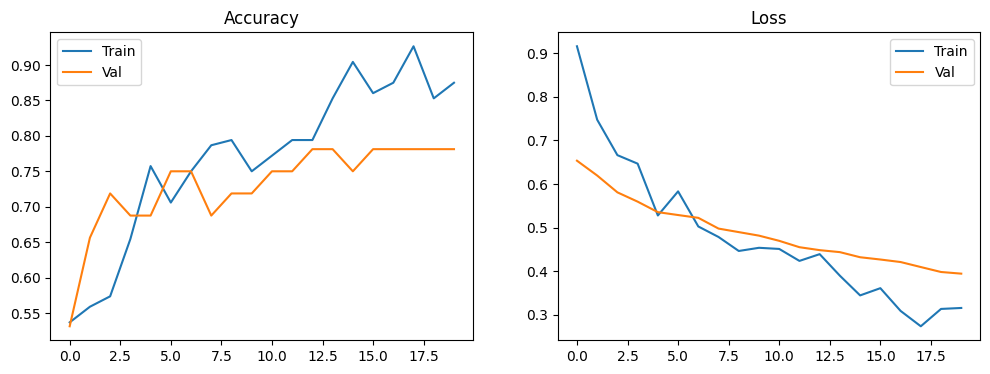

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


2/2 [==============================] - 2s 400ms/step


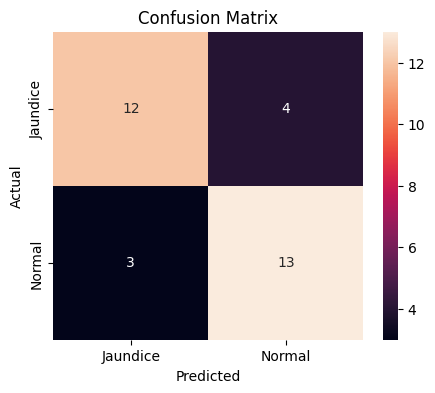

In [15]:
y_true = val_generator.classes
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Jaundice","Normal"],
            yticklabels=["Jaundice","Normal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [16]:
print(classification_report(
    y_true, y_pred,
    target_names=["Jaundice","Normal"]
))


              precision    recall  f1-score   support

    Jaundice       0.80      0.75      0.77        16
      Normal       0.76      0.81      0.79        16

    accuracy                           0.78        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.78      0.78      0.78        32



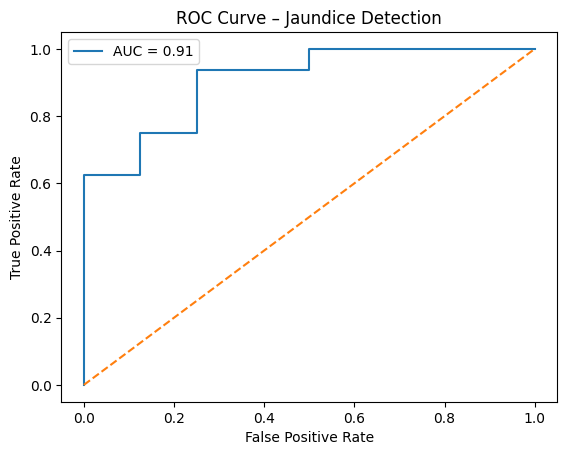

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Jaundice Detection")
plt.legend()
plt.show()


In [18]:
def predict_single_image(img_path):
    img = preprocess_image(img_path)
    img = np.expand_dims(img, axis=0)

    prob = model.predict(img)[0][0]
    label = "Normal" if prob > 0.5 else "Jaundice"
    confidence = (prob if label=="Normal" else 1-prob) * 100

    print("Prediction:", label)
    print("Confidence:", f"{confidence:.2f}%")

    plt.imshow(cv2.imread(img_path)[:,:,::-1])
    plt.title(f"{label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()


In [ ]:
predict_single_image("Downloads/Jaundice Eyes//Jaundice/sample.jpg")
